In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [2]:
import h5py

In [3]:
mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\ethernet_packets_10_5cm_water.mat'

In [4]:
with h5py.File(mat_file, 'r') as f:
    reference_packet = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [5]:
air_exposed_mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\ethernet_packets_10_5cm_air.mat'

In [6]:
with h5py.File(air_exposed_mat_file, 'r') as f:
    reference_packet_air = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [7]:
reference_packet = reference_packet[4,:]
reference_packet_air = reference_packet_air[0,:]

In [8]:
reference_packet


array([0.34585938, 0.221875  , 0.14914062, ..., 0.22523438, 0.2915625 ,
       0.4696875 ], shape=(250000,))

In [9]:
reference_packet_air

array([ 0.83460937,  0.69382813,  0.5815625 , ..., -0.81171875,
       -0.8290625 , -0.84835938], shape=(250000,))

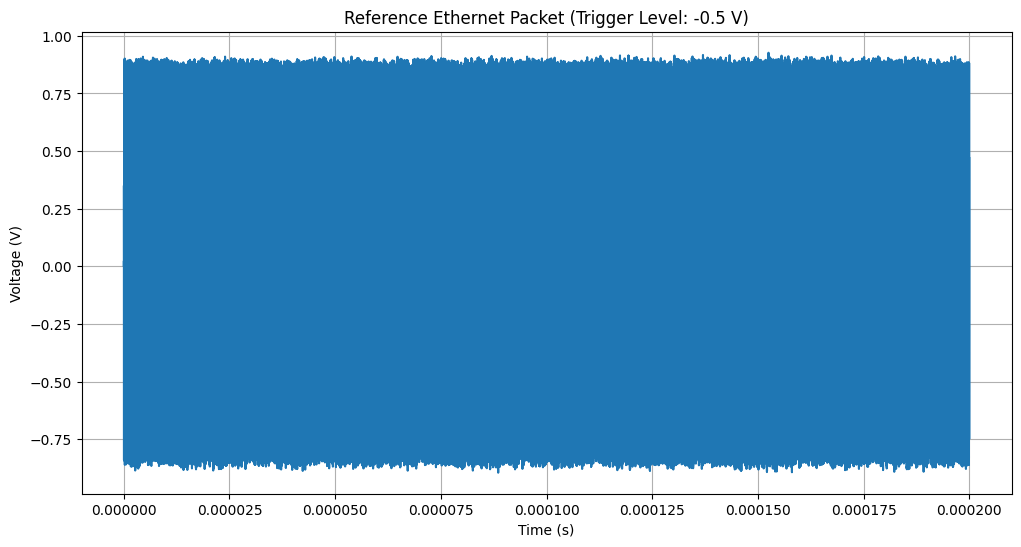

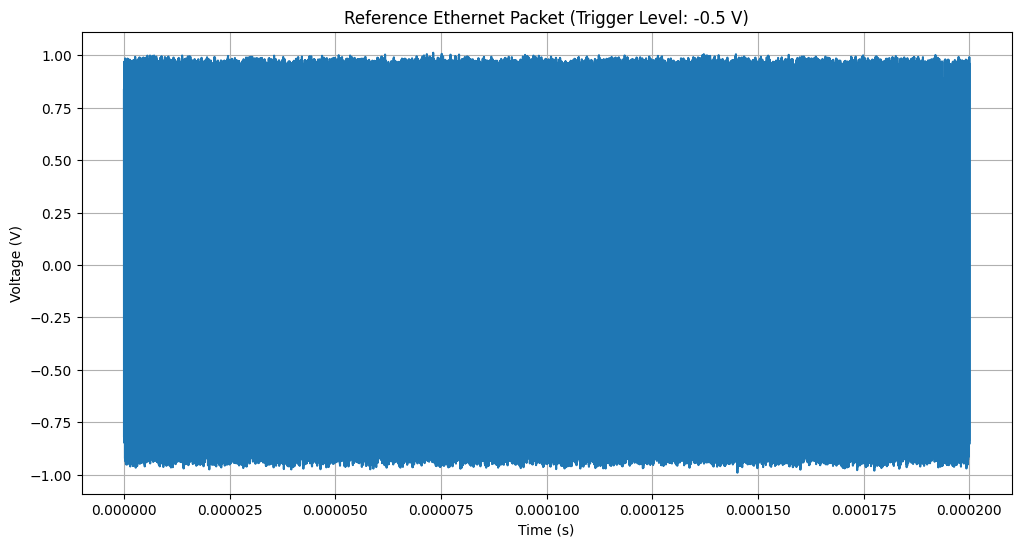

In [10]:
time_axis = np.arange(record_length) / sample_rate
for packet in reference_packet, reference_packet_air:
    plt.figure(figsize=(12,6))
    plt.plot(time_axis, packet, label='Packet')  # Plot each packet
    plt.title(f'Reference Ethernet Packet (Trigger Level: {trigger_level} V)')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.show()

In [11]:
def extract_signal_region(signal, threshold=0.1):
    """Trims the quiet parts of the signal before and after the packet."""
    active = np.abs(signal) > threshold
    indices = np.where(active)[0]
    if indices.size == 0:
        return np.array([])
    return signal[indices[0] : indices[-1] + 1]

In [12]:
reference_packet = extract_signal_region(reference_packet, threshold=0.1)
reference_packet_air = extract_signal_region(reference_packet_air, threshold=0.2)

In [13]:
len(reference_packet), len(reference_packet_air)

(250000, 250000)

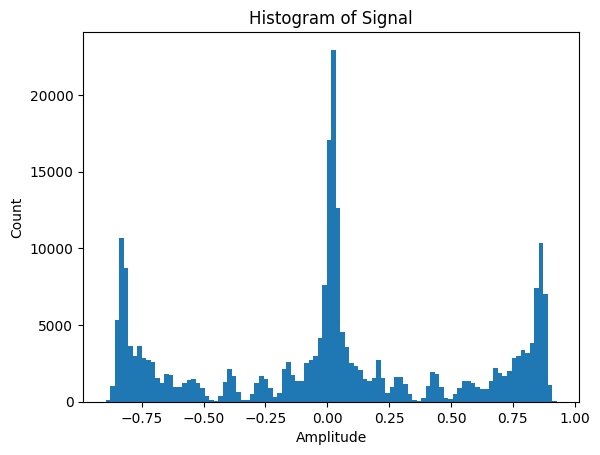

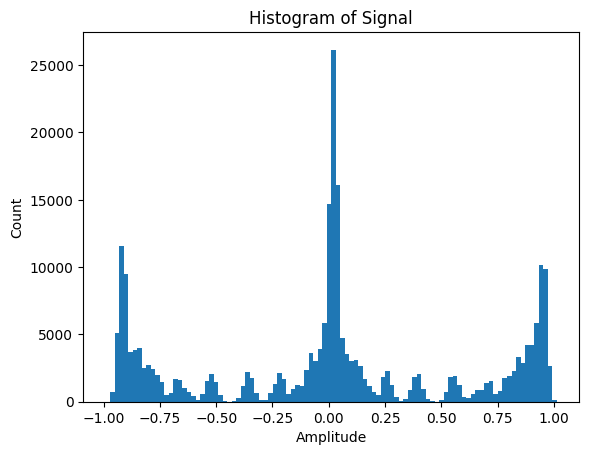

In [14]:
signal = reference_packet  # replace this
for packet in reference_packet, reference_packet_air:
    signal = packet
    plt.figure()
    plt.hist(signal, bins=100)
    plt.title("Histogram of Signal")
    plt.xlabel("Amplitude")
    plt.ylabel("Count")
    plt.show()

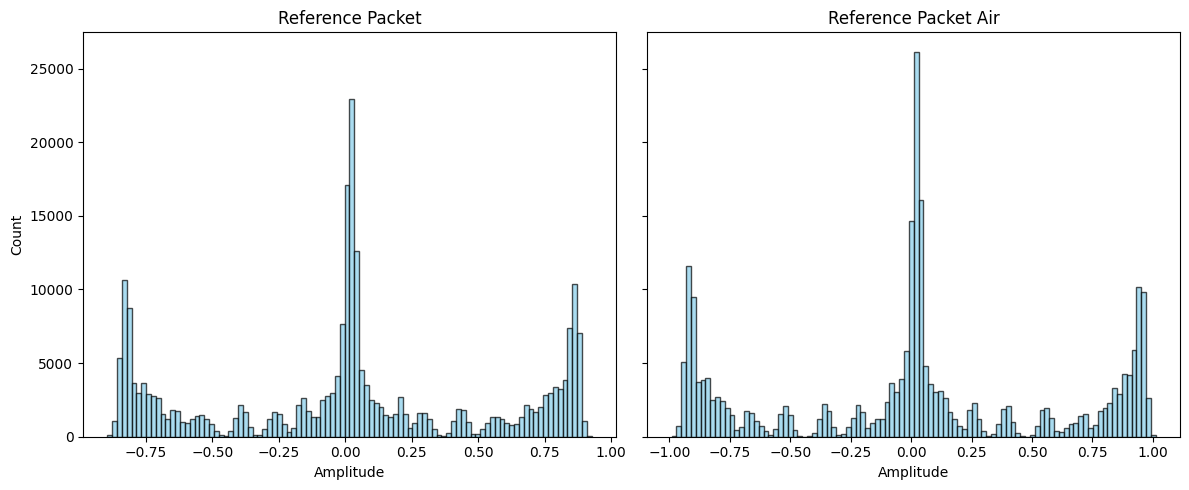

In [15]:
# Data setup
packets = [reference_packet, reference_packet_air]
titles = ["Reference Packet", "Reference Packet Air"]

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, packet in enumerate(packets):
    axes[i].hist(packet, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Amplitude")
    
    # Only label the leftmost y-axis to keep it clean
    if i == 0:
        axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

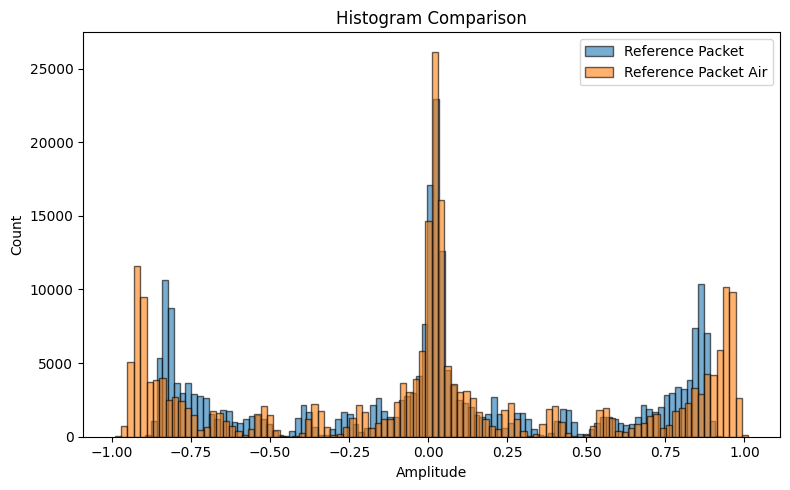

In [16]:
import matplotlib.pyplot as plt

# Data setup
packets = [reference_packet, reference_packet_air]
labels = ["Reference Packet", "Reference Packet Air"]

plt.figure(figsize=(8, 5))

# Plot both histograms on the same axes
plt.hist(reference_packet, bins=100, alpha=0.6, label="Reference Packet", edgecolor='black')
plt.hist(reference_packet_air, bins=100, alpha=0.6, label="Reference Packet Air", edgecolor='black')

plt.title("Histogram Comparison")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# =========================
# 3. REMOVE DC OFFSET
# =========================
signal_dc = reference_packet - np.mean(reference_packet)
signal_air_dc = reference_packet_air - np.mean(reference_packet_air)

In [18]:
window = np.hanning(len(signal_dc))
signal_win = signal_dc * window

In [19]:
window_air = np.hanning(len(signal_air_dc))
signal_air_win = signal_air_dc * window_air

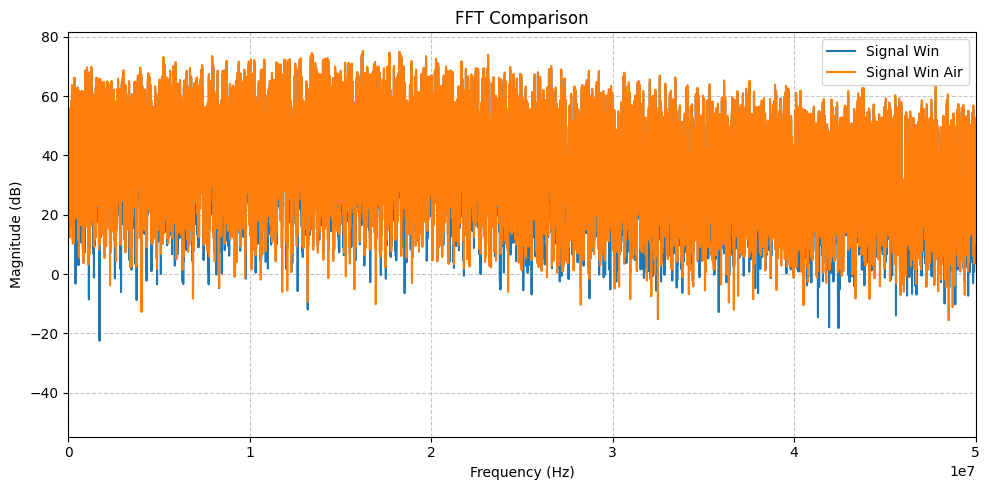

In [20]:
# Define signals
signals = [signal_win, signal_air_win]
labels = ["Signal Win", "Signal Win Air"]
fs = 1.25e9  # Sampling rate

plt.figure(figsize=(10, 5))

for sig, label in zip(signals, labels):
    N = len(sig)
    
    fft_vals = fft(sig)
    freqs = fftfreq(N, 1/fs)
    
    # Magnitude in dB
    magnitude_db = 20 * np.log10(np.abs(fft_vals[:N//2]) + 1e-12)
    
    plt.plot(freqs[:N//2], magnitude_db, label=label)

# Formatting
plt.title("FFT Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 50e6)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

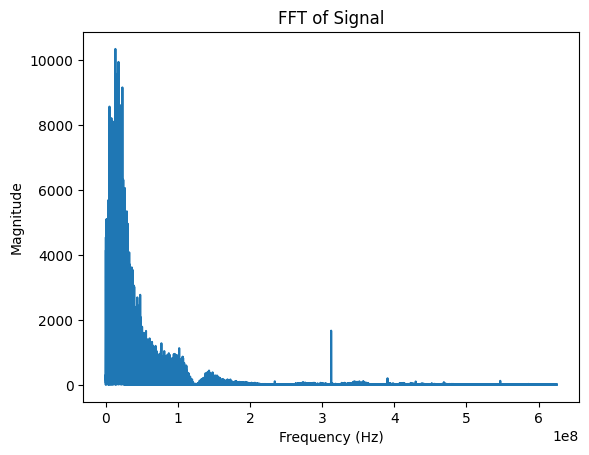

In [21]:
from scipy.fft import fft, fftfreq

N = len(signal)
fs = 1.25e9  # Red Pitaya sampling rate (adjust if different)

fft_vals = fft(signal)
freqs = fftfreq(N, 1/fs)

plt.figure()
plt.plot(freqs[:N//2], np.abs(fft_vals[:N//2]))
plt.title("FFT of Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()